In [70]:
%matplotlib inline

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
    recall_score,
    precision_score,
    accuracy_score,
)

sns.set_theme(style="whitegrid")

train = pd.read_csv("../data/train.csv")
test  = pd.read_csv("../data/test.csv")

X_train = train.drop(columns=["RiskLevel"])
y_train = train["RiskLevel"]
X_test  = test.drop(columns=["RiskLevel"])
y_test  = test["RiskLevel"]

LABELS = ["low risk", "mid risk", "high risk"]
print(X_train.shape, y_train.value_counts().to_dict())

(360, 6) {'low risk': 186, 'high risk': 89, 'mid risk': 85}


## Logistic Regression
## Подбор гиперпараметров
Стратифицированный 5-fold CV, метрика отбора — f1_macro.

In [71]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        class_weight="balanced",
        max_iter=4000,
        random_state=42,
    )),
])

C_grid = np.logspace(-2, 2, 9)  # 0.01 … 100

param_grid = [{
    "clf__solver": ["saga"],
    "clf__C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100],
    "clf__l1_ratio": [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    "clf__class_weight": ["balanced", None],
}]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = GridSearchCV(
    pipe, param_grid,
    scoring="f1_macro",
    cv=cv, n_jobs=-1, refit=True,
    return_train_score=True,
)

t0 = time.perf_counter()
search.fit(X_train, y_train)
print(f"grid search: {time.perf_counter() - t0:.1f} сек")
print("best:", search.best_params_)
print(f"CV f1_macro: {search.best_score_:.3f} ± {search.cv_results_['std_test_score'][search.best_index_]:.3f}")

grid search: 3.3 сек
best: {'clf__C': 0.03, 'clf__class_weight': 'balanced', 'clf__l1_ratio': 0.5, 'clf__solver': 'saga'}
CV f1_macro: 0.601 ± 0.030


## Топ комбинаций по CV

In [72]:
res = pd.DataFrame(search.cv_results_)
cols = [c for c in res.columns if c.startswith("param_")] + [
    "mean_test_score", "std_test_score", "mean_train_score", "mean_fit_time"
]
display(res[cols].sort_values("mean_test_score", ascending=False).head(12).round(3))

,param_clf__C,param_clf__class_weight,param_clf__l1_ratio,param_clf__solver,mean_test_score,std_test_score,mean_train_score,mean_fit_time
27,0.03,balanced,0.5,saga,0.601,0.030,0.621,0.008
28,0.03,balanced,0.6,saga,0.597,0.033,0.616,0.008
29,0.03,balanced,0.7,saga,0.596,0.034,0.604,0.009
1,0.01,balanced,0.1,saga,0.589,0.039,0.602,0.010
26,0.03,balanced,0.4,saga,0.585,0.029,0.621,0.007
30,0.03,balanced,0.8,saga,0.581,0.036,0.594,0.007
2,0.01,balanced,0.2,saga,0.580,0.047,0.592,0.010
25,0.03,balanced,0.3,saga,0.579,0.025,0.606,0.006
24,0.03,balanced,0.2,saga,0.576,0.028,0.607,0.008
23,0.03,balanced,0.1,saga,0.575,0.021,0.595,0.008


## OOF-оценка на train
Честное качество без теста. ± из сетки — разброс по фолдам.

In [73]:
oof = cross_val_predict(search.best_estimator_, X_train, y_train, cv=cv, n_jobs=-1)

print(f"OOF accuracy : {accuracy_score(y_train, oof):.3f}")
print(f"OOF f1_macro : {f1_score(y_train, oof, average='macro'):.3f}")
print("OOF recall    :", dict(zip(
    LABELS,
    recall_score(y_train, oof, labels=LABELS, average=None).round(3),
)))
print("OOF precision :", dict(zip(
    LABELS,
    precision_score(y_train, oof, labels=LABELS, average=None).round(3),
)))
print()
print(classification_report(y_train, oof, labels=LABELS, digits=3))

OOF accuracy : 0.669
OOF f1_macro : 0.604
OOF recall    : {'low risk': np.float64(0.849), 'mid risk': np.float64(0.318), 'high risk': np.float64(0.629)}
OOF precision : {'low risk': np.float64(0.756), 'mid risk': np.float64(0.375), 'high risk': np.float64(0.709)}

              precision    recall  f1-score   support

    low risk      0.756     0.849     0.800       186
    mid risk      0.375     0.318     0.344        85
   high risk      0.709     0.629     0.667        89

    accuracy                          0.669       360
   macro avg      0.613     0.599     0.604       360
weighted avg      0.654     0.669     0.659       360



## Матрица ошибок OOF
Слева штуки, справа доля по истинному классу (recall).

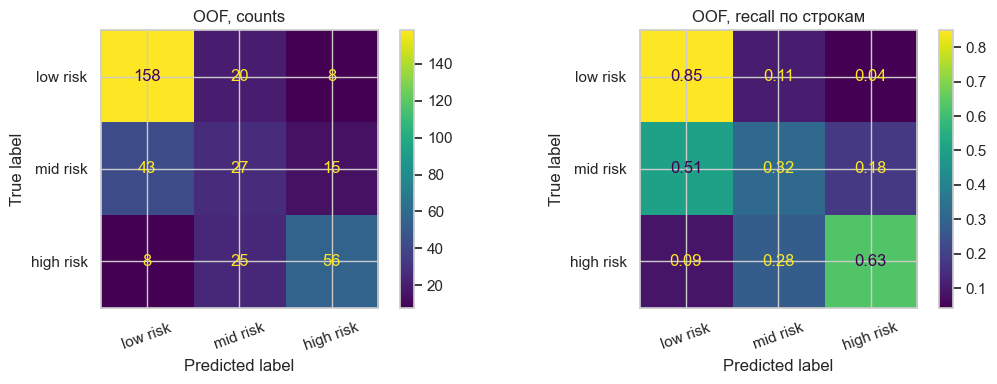

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_predictions(
    y_train, oof, labels=LABELS, ax=axes[0], xticks_rotation=20
)
axes[0].set_title("OOF, counts")

ConfusionMatrixDisplay.from_predictions(
    y_train, oof, labels=LABELS, normalize="true",
    values_format=".2f", ax=axes[1], xticks_rotation=20
)
axes[1].set_title("OOF, recall по строкам")
plt.tight_layout()
plt.show()

## Precision / recall / F1 по классам (OOF)

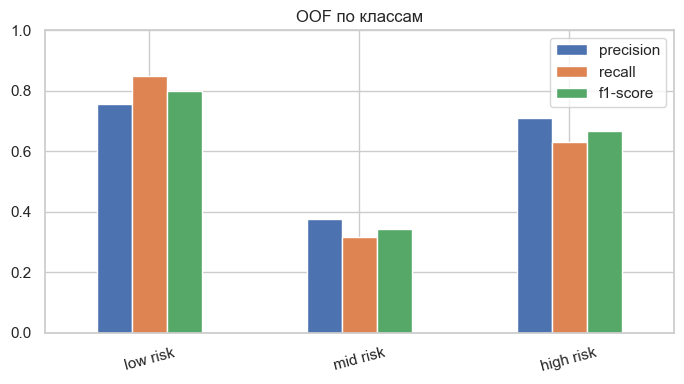

,precision,recall,f1-score
low risk,0.756,0.849,0.800
mid risk,0.375,0.318,0.344
high risk,0.709,0.629,0.667


In [75]:
rep = classification_report(y_train, oof, labels=LABELS, output_dict=True)
per = pd.DataFrame(rep).T.loc[LABELS, ["precision", "recall", "f1-score"]]
per.plot(kind="bar", ylim=(0, 1), figsize=(7, 4))
plt.xticks(rotation=15)
plt.title("OOF по классам")
plt.tight_layout()
plt.show()
display(per.round(3))

## SVM
## Подбор гиперпараметров

In [76]:
from sklearn.svm import SVC

svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(class_weight="balanced", random_state=42)),
])

svm_grid = [
    {
        "clf__kernel": ["linear"],
        "clf__C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100],
        "clf__class_weight": ["balanced", None],
    },
    {
        "clf__kernel": ["rbf"],
        "clf__C": [0.1, 0.3, 1, 3, 10, 30, 100],
        "clf__gamma": ["scale", 0.01, 0.03, 0.1, 0.3, 1],
        "clf__class_weight": ["balanced", None],
    },
]

svm_search = GridSearchCV(
    svm_pipe, svm_grid,
    scoring="f1_macro",
    cv=cv, n_jobs=-1, refit=True,
    return_train_score=True,
)

t0 = time.perf_counter()
svm_search.fit(X_train, y_train)
print(f"grid search: {time.perf_counter() - t0:.1f} сек")
print("best:", svm_search.best_params_)
print(f"CV f1_macro: {svm_search.best_score_:.3f} ± {svm_search.cv_results_['std_test_score'][svm_search.best_index_]:.3f}")

grid search: 1.5 сек
best: {'clf__C': 100, 'clf__class_weight': 'balanced', 'clf__gamma': 0.03, 'clf__kernel': 'rbf'}
CV f1_macro: 0.676 ± 0.017


## Топ комбинаций по CV

In [77]:
res = pd.DataFrame(svm_search.cv_results_)
cols = [c for c in res.columns if c.startswith("param_")] + [
    "mean_test_score", "std_test_score", "mean_train_score", "mean_fit_time"
]
display(res[cols].sort_values("mean_test_score", ascending=False).head(12).round(3))

,param_clf__C,param_clf__class_weight,param_clf__kernel,param_clf__gamma,mean_test_score,std_test_score,mean_train_score,mean_fit_time
92,100.0,balanced,rbf,0.03,0.676,0.017,0.740,0.013
69,10.0,balanced,rbf,0.1,0.658,0.016,0.751,0.011
98,100.0,None,rbf,0.03,0.649,0.046,0.733,0.014
54,3.0,balanced,rbf,scale,0.645,0.029,0.749,0.013
75,10.0,None,rbf,0.1,0.637,0.042,0.744,0.010
57,3.0,balanced,rbf,0.1,0.633,0.040,0.716,0.012
91,100.0,balanced,rbf,0.01,0.631,0.033,0.682,0.013
80,30.0,balanced,rbf,0.03,0.631,0.037,0.714,0.012
60,3.0,None,rbf,scale,0.626,0.035,0.734,0.014
34,0.3,balanced,rbf,0.3,0.624,0.055,0.693,0.011


## OOF-оценка на train

In [78]:
svm_oof = cross_val_predict(svm_search.best_estimator_, X_train, y_train, cv=cv, n_jobs=-1)

print("best:", svm_search.best_params_)
print(f"CV f1_macro: {svm_search.best_score_:.3f} ± {svm_search.cv_results_['std_test_score'][svm_search.best_index_]:.3f}")
print(f"OOF accuracy : {accuracy_score(y_train, svm_oof):.3f}")
print(f"OOF f1_macro : {f1_score(y_train, svm_oof, average='macro'):.3f}")
print("OOF recall    :", dict(zip(LABELS, recall_score(y_train, svm_oof, labels=LABELS, average=None).round(3))))
print("OOF precision :", dict(zip(LABELS, precision_score(y_train, svm_oof, labels=LABELS, average=None).round(3))))
print()
print(classification_report(y_train, svm_oof, labels=LABELS, digits=3))

best: {'clf__C': 100, 'clf__class_weight': 'balanced', 'clf__gamma': 0.03, 'clf__kernel': 'rbf'}
CV f1_macro: 0.676 ± 0.017
OOF accuracy : 0.725
OOF f1_macro : 0.680
OOF recall    : {'low risk': np.float64(0.839), 'mid risk': np.float64(0.412), 'high risk': np.float64(0.787)}
OOF precision : {'low risk': np.float64(0.78), 'mid risk': np.float64(0.507), 'high risk': np.float64(0.769)}

              precision    recall  f1-score   support

    low risk      0.780     0.839     0.808       186
    mid risk      0.507     0.412     0.455        85
   high risk      0.769     0.787     0.778        89

    accuracy                          0.725       360
   macro avg      0.685     0.679     0.680       360
weighted avg      0.713     0.725     0.717       360



## Матрица ошибок OOF

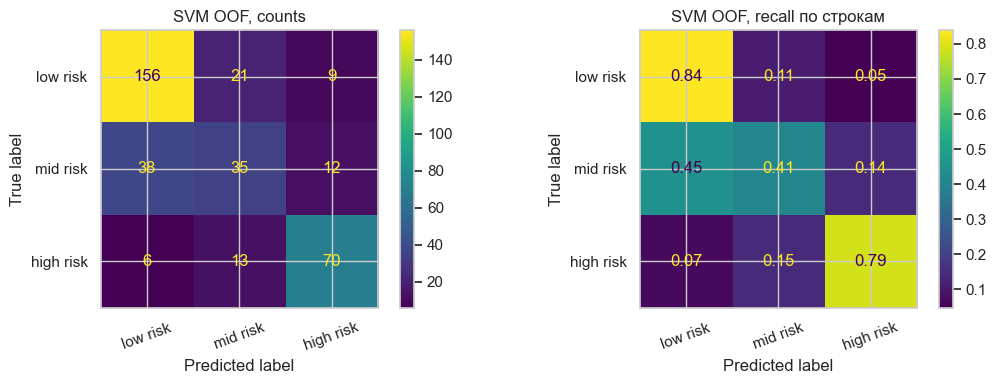

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_predictions(
    y_train, svm_oof, labels=LABELS, ax=axes[0], xticks_rotation=20
)
axes[0].set_title("SVM OOF, counts")
ConfusionMatrixDisplay.from_predictions(
    y_train, svm_oof, labels=LABELS, normalize="true",
    values_format=".2f", ax=axes[1], xticks_rotation=20
)
axes[1].set_title("SVM OOF, recall по строкам")
plt.tight_layout()
plt.show()

## Precision / recall / F1 по классам (OOF)

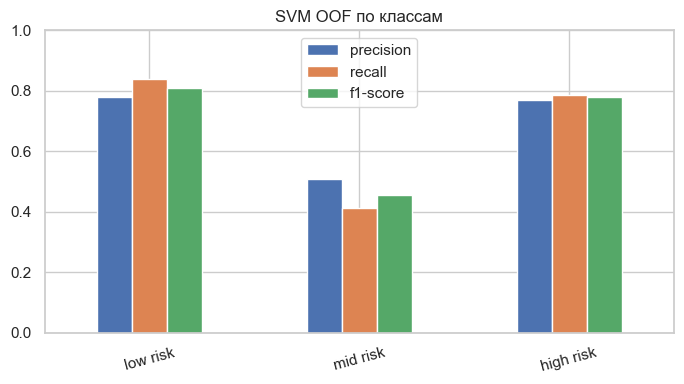

,precision,recall,f1-score
low risk,0.780,0.839,0.808
mid risk,0.507,0.412,0.455
high risk,0.769,0.787,0.778


In [80]:
rep = classification_report(y_train, svm_oof, labels=LABELS, output_dict=True)
per = pd.DataFrame(rep).T.loc[LABELS, ["precision", "recall", "f1-score"]]
per.plot(kind="bar", ylim=(0, 1), figsize=(7, 4))
plt.xticks(rotation=15)
plt.title("SVM OOF по классам")
plt.tight_layout()
plt.show()
display(per.round(3))

## Decision Tree
## Подбор гиперпараметров
Глубину и лист режем специально, иначе дерево зазубривает train.

In [81]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=42, max_features=None)

tree_space = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 4, 5, 6, 8, 10, 12],
    "min_samples_leaf": [1, 2, 4, 6, 8, 12],
    "min_samples_split": [2, 8, 16],
    "class_weight": ["balanced", None],
    "ccp_alpha": [0.0, 0.001, 0.003, 0.01, 0.02],
}

tree_search = RandomizedSearchCV(
    tree,
    tree_space,
    n_iter=500,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    refit=True,
    return_train_score=True,
)

t0 = time.perf_counter()
tree_search.fit(X_train, y_train)
print(f"random search: {time.perf_counter() - t0:.1f} сек")
print("best:", tree_search.best_params_)
print(f"CV f1_macro: {tree_search.best_score_:.3f} ± {tree_search.cv_results_['std_test_score'][tree_search.best_index_]:.3f}")

random search: 11.3 сек
best: {'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 5, 'criterion': 'entropy', 'class_weight': 'balanced', 'ccp_alpha': 0.02}
CV f1_macro: 0.671 ± 0.023


## Топ комбинаций по CV

In [82]:
res = pd.DataFrame(tree_search.cv_results_)
cols = [c for c in res.columns if c.startswith("param_")] + [
    "mean_test_score", "std_test_score", "mean_train_score", "mean_fit_time"
]
display(res[cols].sort_values("mean_test_score", ascending=False).head(12).round(3))

,param_min_samples_split,param_min_samples_leaf,param_max_depth,param_criterion,param_class_weight,param_ccp_alpha,mean_test_score,std_test_score,mean_train_score,mean_fit_time
471,16,4,5,entropy,balanced,0.020,0.671,0.023,0.709,0.003
46,2,4,5,entropy,balanced,0.020,0.671,0.023,0.709,0.003
369,2,1,5,entropy,balanced,0.020,0.670,0.023,0.714,0.003
470,16,2,4,entropy,balanced,0.020,0.664,0.027,0.702,0.004
468,2,6,10,entropy,balanced,0.020,0.664,0.031,0.706,0.003
166,2,4,6,entropy,balanced,0.020,0.664,0.031,0.706,0.004
4,8,4,8,entropy,balanced,0.020,0.664,0.031,0.709,0.003
376,8,1,6,entropy,balanced,0.020,0.662,0.031,0.711,0.004
191,2,2,8,entropy,balanced,0.020,0.662,0.031,0.711,0.003
242,16,2,4,gini,balanced,0.001,0.662,0.029,0.709,0.003


## OOF-оценка на train

In [83]:
tree_oof = cross_val_predict(tree_search.best_estimator_, X_train, y_train, cv=cv, n_jobs=-1)

print("best:", tree_search.best_params_)
print(f"CV f1_macro: {tree_search.best_score_:.3f} ± {tree_search.cv_results_['std_test_score'][tree_search.best_index_]:.3f}")
print(f"OOF accuracy : {accuracy_score(y_train, tree_oof):.3f}")
print(f"OOF f1_macro : {f1_score(y_train, tree_oof, average='macro'):.3f}")
print("OOF recall    :", dict(zip(LABELS, recall_score(y_train, tree_oof, labels=LABELS, average=None).round(3))))
print("OOF precision :", dict(zip(LABELS, precision_score(y_train, tree_oof, labels=LABELS, average=None).round(3))))
print()
print(classification_report(y_train, tree_oof, labels=LABELS, digits=3))

best: {'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 5, 'criterion': 'entropy', 'class_weight': 'balanced', 'ccp_alpha': 0.02}
CV f1_macro: 0.671 ± 0.023
OOF accuracy : 0.733
OOF f1_macro : 0.672
OOF recall    : {'low risk': np.float64(0.882), 'mid risk': np.float64(0.353), 'high risk': np.float64(0.787)}
OOF precision : {'low risk': np.float64(0.792), 'mid risk': np.float64(0.508), 'high risk': np.float64(0.745)}

              precision    recall  f1-score   support

    low risk      0.792     0.882     0.835       186
    mid risk      0.508     0.353     0.417        85
   high risk      0.745     0.787     0.765        89

    accuracy                          0.733       360
   macro avg      0.682     0.674     0.672       360
weighted avg      0.713     0.733     0.719       360



## Матрица ошибок OOF

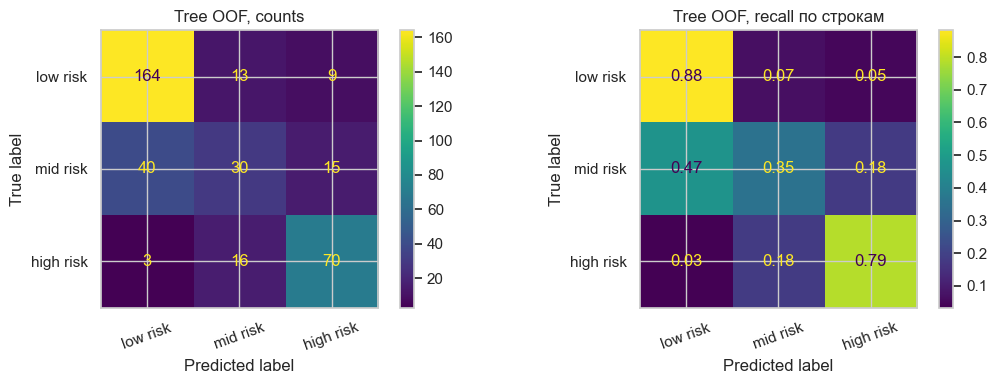

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_predictions(
    y_train, tree_oof, labels=LABELS, ax=axes[0], xticks_rotation=20
)
axes[0].set_title("Tree OOF, counts")
ConfusionMatrixDisplay.from_predictions(
    y_train, tree_oof, labels=LABELS, normalize="true",
    values_format=".2f", ax=axes[1], xticks_rotation=20
)
axes[1].set_title("Tree OOF, recall по строкам")
plt.tight_layout()
plt.show()

## Precision / recall / F1 по классам (OOF)

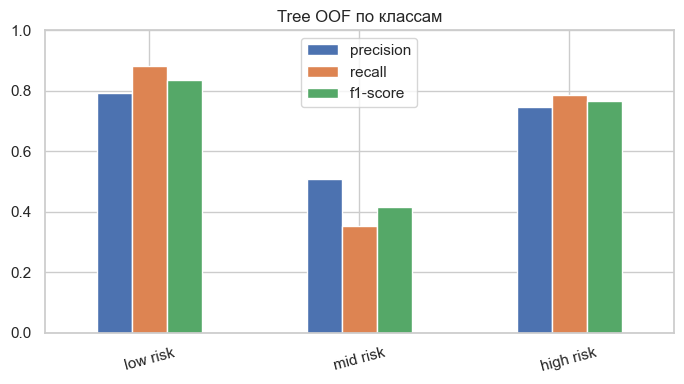

,precision,recall,f1-score
low risk,0.792,0.882,0.835
mid risk,0.508,0.353,0.417
high risk,0.745,0.787,0.765


In [85]:
rep = classification_report(y_train, tree_oof, labels=LABELS, output_dict=True)
per = pd.DataFrame(rep).T.loc[LABELS, ["precision", "recall", "f1-score"]]
per.plot(kind="bar", ylim=(0, 1), figsize=(7, 4))
plt.xticks(rotation=15)
plt.title("Tree OOF по классам")
plt.tight_layout()
plt.show()
display(per.round(3))